In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/yolov9-main

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
ln: failed to create symbolic link '/mydrive/My Drive': File exists
/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main


In [7]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("markerpensseg/train")
count_images("markerpensseg/valid")

Total images: 225
Total images: 30


In [8]:
# Check train annotations
with open("markerpensseg/train/_annotations.coco.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("markerpensseg/valid/_annotations.coco.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 225
Train annotations: 450
Categories: [{'id': 0, 'name': 'caps-7o2C', 'supercategory': 'none'}, {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C'}]

Valid images: 30
Valid annotations: 60


In [9]:
import json
from collections import defaultdict
from pprint import pprint

def check_coco_instance_segmentation(ann_file_path):
    with open(ann_file_path, 'r') as f:
        coco_data = json.load(f)

    # Top-level keys
    assert 'images' in coco_data, "'images' key not found"
    assert 'annotations' in coco_data, "'annotations' key not found"
    assert 'categories' in coco_data, "'categories' key not found"

    print(f"📷 Total images: {len(coco_data['images'])}")
    print(f"✏️ Total annotations: {len(coco_data['annotations'])}")
    print(f"🏷️ Total categories: {len(coco_data['categories'])}")

    print("\n🔍 Sample category definitions:")
    pprint(coco_data['categories'])

    # Required annotation fields
    required_fields = {"id", "image_id", "bbox", "category_id", "segmentation"}
    optional_fields = ["iscrowd", "area"]
    missing_fields = defaultdict(list)
    bad_segmentations = []

    for i, ann in enumerate(coco_data['annotations']):
        for field in required_fields:
            if field not in ann:
                missing_fields[field].append(i)

        # Check segmentation format: must be non-empty polygon(s)
        seg = ann.get("segmentation", [])
        if not isinstance(seg, list) or len(seg) == 0:
            bad_segmentations.append((i, "Empty or invalid segmentation"))
        else:
            for poly in seg:
                if not isinstance(poly, list) or len(poly) < 6 or len(poly) % 2 != 0:
                    bad_segmentations.append((i, f"Invalid polygon: {poly}"))

    # Report missing fields
    for field, indices in missing_fields.items():
        print(f"⚠️ Missing '{field}' in {len(indices)} annotations. Examples: {indices[:5]}")
    if not missing_fields:
        print("✅ All required fields are present in every annotation")

    # Report segmentation issues
    if bad_segmentations:
        print(f"⚠️ Found {len(bad_segmentations)} invalid/malformed segmentations.")
        for i, reason in bad_segmentations[:5]:
            print(f"  Annotation {i}: {reason}")
    else:
        print("✅ All segmentations are well-formed polygons")

    # Optional fields
    for field in optional_fields:
        missing = sum(1 for ann in coco_data['annotations'] if field not in ann)
        if missing > 0:
            print(f"⚠️ Missing optional '{field}' in {missing} annotations")
        else:
            print(f"✅ All annotations have optional field '{field}'")

# Example usage:
check_coco_instance_segmentation("markerpensseg/train/_annotations.coco.json")

📷 Total images: 225
✏️ Total annotations: 450
🏷️ Total categories: 2

🔍 Sample category definitions:
[{'id': 0, 'name': 'caps-7o2C', 'supercategory': 'none'},
 {'id': 1, 'name': 'CAP', 'supercategory': 'caps-7o2C'}]
✅ All required fields are present in every annotation
✅ All segmentations are well-formed polygons
✅ All annotations have optional field 'iscrowd'
✅ All annotations have optional field 'area'


In [2]:
!git clone https://github.com/facebookresearch/detectron2.git
%cd detectron2

fatal: destination path 'detectron2' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main/detectron2


In [ ]:
!pip install -U 'git+https://github.com/facebookresearch/detectron2.git'

In [3]:
import sys
import os
import yaml
import numpy as np
import torch

sys.path.insert(0, '/content/gdrive/MyDrive/Hugging Face/detectron2')

In [4]:
%cd /content/gdrive/MyDrive/yolov9-main/

/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main


In [5]:
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

<Logger detectron2 (DEBUG)>

In [6]:
from detectron2.data.datasets import register_coco_instances
import os

data_dir = "markerpensseg"

register_coco_instances("marker_train", {},
                        os.path.join(data_dir, "train/_annotations.coco.json"),
                        os.path.join(data_dir, "train"))

register_coco_instances("marker_val", {},
                        os.path.join(data_dir, "valid/_annotations.coco.json"),
                        os.path.join(data_dir, "valid"))

In [7]:
!git clone https://github.com/facebookresearch/Mask2Former.git
%cd Mask2Former

fatal: destination path 'Mask2Former' already exists and is not an empty directory.
/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main/Mask2Former


In [ ]:
!pip install -r requirements.txt
%cd ..

In [22]:
!sed -i 's/value.type()/value.scalar_type()/g' Mask2Former/mask2former/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu
!sed -i 's/value.scalar_type().is_cuda()/value.is_cuda()/g' Mask2Former/mask2former/modeling/pixel_decoder/ops/src/cuda/ms_deform_attn_cuda.cu

In [8]:
make_script = """
#!/usr/bin/env bash
TORCH_CUDA_ARCH_LIST="All" python setup.py build_ext --inplace
"""

ops_dir = "/content/gdrive/MyDrive/yolov9-main/Mask2Former/mask2former/modeling/pixel_decoder/ops"

import os
os.makedirs(ops_dir, exist_ok=True)  # just in case

with open(os.path.join(ops_dir, "make.sh"), "w") as f:
    f.write(make_script)

# Make executable
!chmod +x "{os.path.join(ops_dir, 'make.sh')}"

In [18]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 5.2 MB/s eta 0:00:00


In [9]:
%cd /content/gdrive/MyDrive/yolov9-main/Mask2Former/mask2former/modeling/pixel_decoder/ops
!python setup.py build_ext --inplace

/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main/Mask2Former/mask2former/modeling/pixel_decoder/ops
running build_ext
W0402 08:33:29.958000 24233 torch/utils/cpp_extension.py:535] There are no x86_64-linux-gnu-g++ version bounds defined for CUDA version 12.8
building 'MultiScaleDeformableAttention' extension
ninja: no work to do.
x86_64-linux-gnu-g++ -fno-strict-overflow -Wsign-compare -DNDEBUG -g -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g -fwrapv -O2 -shared -Wl,-O1 -Wl,-Bsymbolic-functions -Wl,-Bsymbolic-functions -g -fwrapv -O2 /content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main/Mask2Former/mask2former/modeling/pixel_decoder/ops/build/temp.linux-x86_64-cpython-312/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main/Mask2Former/mask2former/modeling/pixel_decoder/ops/src/cpu/ms_deform_attn_cpu.o /content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b31

In [10]:
import os
import detectron2
from PIL import Image
import re

# 1. Ensure Pillow is new enough
print(f"Pillow version: {Image.__version__}")
if not hasattr(Image, "Resampling"):
    raise RuntimeError("You must upgrade pillow >=10.1")

# 2. Locate detectron2 install
d2_dir = os.path.dirname(detectron2.__file__)
print("Detectron2 installed at:", d2_dir)

# 3. Target the file to patch
target = os.path.join(d2_dir, "data", "transforms", "transform.py")

# 4. Replace deprecated Pillow constants
with open(target, "r") as f:
    code = f.read()

patched = re.sub(r"Image\.LINEAR", "Image.Resampling.BILINEAR", code)

with open(target, "w") as f:
    f.write(patched)

print("✅ Patched:", target)

Pillow version: 11.3.0
Detectron2 installed at: /content/gdrive/MyDrive/Hugging Face/detectron2/detectron2
✅ Patched: /content/gdrive/MyDrive/Hugging Face/detectron2/detectron2/data/transforms/transform.py


In [11]:
import sys
sys.path.append("/content/gdrive/MyDrive/yolov9-main/Mask2Former/mask2former/modeling/pixel_decoder/ops/build/lib.linux-x86_64-cpython-311")

import os
os.environ['PYTHONPATH'] = os.environ.get('PYTHONPATH', '') + ':/content/gdrive/MyDrive/yolov9-main/Mask2Former/mask2former/modeling/pixel_decoder/ops/build/lib.linux-x86_64-cpython-311'

# Just test it's available
import MultiScaleDeformableAttention
print("MultiScaleDeformableAttention module loaded successfully!")

MultiScaleDeformableAttention module loaded successfully!


In [12]:
sys.path.insert(0, '/content/gdrive/MyDrive/yolov9-main/Mask2Former')

In [13]:
%cd /content/gdrive/MyDrive/yolov9-main/Mask2Former/

/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main/Mask2Former


In [15]:
# import Mask2Former project
from mask2former.config import add_maskformer2_config

In [16]:
%cd /content/gdrive/MyDrive/yolov9-main/

/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main


In [29]:
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.projects.deeplab import add_deeplab_config
from mask2former.config import add_maskformer2_config

cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

# Use Mask2Former with ResNet-50
cfg.merge_from_file("Mask2Former/configs/coco/instance-segmentation/maskformer2_R50_bs16_50ep.yaml")
cfg.MODEL.WEIGHTS = "https://dl.fbaipublicfiles.com/maskformer/mask2former/coco/instance/maskformer2_R50_bs16_50ep/model_final_3c8ec9.pkl"

# Dataset
cfg.DATASETS.TRAIN = ("marker_train",)
cfg.DATASETS.TEST = ("marker_val",)
cfg.DATALOADER.NUM_WORKERS = 2

# Training setup
cfg.SOLVER.IMS_PER_BATCH = 2
num_images = 225
epochs = 6
iters_per_epoch = num_images // cfg.SOLVER.IMS_PER_BATCH
cfg.SOLVER.MAX_ITER = iters_per_epoch * epochs
cfg.SOLVER.WARMUP_ITERS = 30
# Dynamic LR step schedule (50% and 80% of total iters)
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.STEPS = (
    int(cfg.SOLVER.MAX_ITER * 0.5),
    int(cfg.SOLVER.MAX_ITER * 0.8)
)
# Evaluate every 2 epochs
cfg.TEST.EVAL_PERIOD = iters_per_epoch * 2 # 2 epoch
cfg.SOLVER.GAMMA = 0.1

cfg.MODEL.SEM_SEG_HEAD.NUM_CLASSES = 2

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.35
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.5

# Most Mask2Former configs expect 'value'
cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE = "value"

cfg.INPUT.MASK_FORMAT = "bitmask"
cfg.MODEL.MASK_ON = True

cfg.SOLVER.CHECKPOINT_PERIOD = iters_per_epoch * 2 # 2 epoch
cfg.OUTPUT_DIR = "/content/.cache/detectron2_marker"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [44]:
!sed -i 's/gt_masks = targets_per_image.gt_masks/gt_masks = targets_per_image.gt_masks.tensor if hasattr(targets_per_image.gt_masks, "tensor") else targets_per_image.gt_masks/g' /content/gdrive/MyDrive/yolov9-main/Mask2Former/mask2former/maskformer_model.py

In [30]:
from detectron2.engine import DefaultTrainer, hooks
from detectron2.evaluation import COCOEvaluator
import torch

from detectron2.evaluation import inference_on_dataset

class BestModelSaver(hooks.EvalHook):
    def __init__(self, eval_period, model, evaluator, val_loader, save_path):
        self.model = model
        self.evaluator = evaluator
        self.val_loader = val_loader
        self.save_path = save_path
        self.best_ap = -1

        def eval_function():
            results = inference_on_dataset(self.model, self.val_loader, self.evaluator)
            if results:
                curr_ap = results["segm"]["AP"]
                print(f"📈 Eval AP: {curr_ap:.4f} | Best so far: {self.best_ap:.4f}")
                if curr_ap > self.best_ap:
                    print(f"🥇 New best model! Saving to {self.save_path}")
                    torch.save(self.model.state_dict(), self.save_path)
                    self.best_ap = curr_ap
            return results

        super().__init__(eval_period, eval_function)

In [31]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from pycocotools.coco import COCO
import copy

class SafeCOCOEvaluator(COCOEvaluator):
    def _evaluate_predictions_on_coco(self, coco_gt: COCO, coco_results, iou_type):
        # 🔧 Patch missing fields to prevent crashing
        coco_gt.dataset.setdefault("info", {})
        coco_gt.dataset.setdefault("licenses", [])
        coco_gt.createIndex()  # Ensure internal COCO indexing is rebuilt

        coco_dt = coco_gt.loadRes(coco_results)
        return super()._evaluate_predictions_on_coco(coco_gt, coco_dt, iou_type)

In [27]:
torch.cuda.empty_cache()

In [32]:
from detectron2.data import build_detection_test_loader

trainer = DefaultTrainer(cfg)

val_loader = build_detection_test_loader(cfg, "marker_val")
evaluator = SafeCOCOEvaluator("marker_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
best_model_path = "datasets/best_Mask2Former_marker.pth"

trainer.register_hooks([
    BestModelSaver(cfg.TEST.EVAL_PERIOD, trainer.model, evaluator, val_loader, best_model_path)
])

from pycocotools.coco import COCO
import copy
import json
import time

def patched_loadRes(self, resFile):
    tic = time.time()  # <-- ✅ define it properly now

    # Ensure required dataset fields exist
    if 'info' not in self.dataset:
        self.dataset['info'] = {}
    if 'licenses' not in self.dataset:
        self.dataset['licenses'] = []

    # Load annotation results from file or list
    if isinstance(resFile, str):
        with open(resFile, 'r') as f:
            anns = json.load(f)
    elif isinstance(resFile, list):
        anns = resFile
    else:
        raise TypeError('resFile must be a file path or list of dicts')

    res = COCO()
    res.dataset['info'] = copy.deepcopy(self.dataset['info'])
    res.dataset['licenses'] = copy.deepcopy(self.dataset['licenses'])
    res.dataset['images'] = copy.deepcopy(self.dataset['images'])

    assert isinstance(anns, list), 'Annotations must be a list'
    anns_img_ids = [ann['image_id'] for ann in anns]
    assert set(anns_img_ids).issubset(set(self.getImgIds()))

    # Add missing 'id' and 'area' fields in each annotation
    for idx, ann in enumerate(anns):
        ann.setdefault('id', idx + 1)
        if 'area' not in ann:
            if 'bbox' in ann:
                _, _, w, h = ann['bbox']
                ann['area'] = w * h
            else:
                ann['area'] = 0

    res.dataset['annotations'] = anns
    res.createIndex()
    print(f'Annotations loaded in {time.time() - tic:.2f}s')
    return res

# ✅ Monkey-patch the method
COCO.loadRes = patched_loadRes

[04/02 08:42:24 d2.engine.defaults]: Model:
MaskFormer(
  (backbone): ResNet(
    (stem): BasicStem(
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
      

In [33]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [34]:
trainer.resume_or_load(resume=True)
trainer.train()

[04/02 08:42:38 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/.cache/detectron2_marker/model_0000223.pth ...
[04/02 08:42:38 d2.engine.hooks]: Loading scheduler from state_dict ...
[04/02 08:42:38 d2.engine.train_loop]: Starting training from iteration 224
[04/02 08:42:55 d2.utils.events]:  eta: 0:07:26  iter: 239  total_loss: 2.787  loss_ce: 0.003042  loss_mask: 0.01385  loss_dice: 0.09617  loss_ce_0: 1.421  loss_mask_0: 0.01873  loss_dice_0: 0.1921  loss_ce_1: 0.03339  loss_mask_1: 0.01254  loss_dice_1: 0.1237  loss_ce_2: 0.01594  loss_mask_2: 0.01426  loss_dice_2: 0.1124  loss_ce_3: 0.004318  loss_mask_3: 0.01327  loss_dice_3: 0.13  loss_ce_4: 0.003097  loss_mask_4: 0.01387  loss_dice_4: 0.1027  loss_ce_5: 0.00283  loss_mask_5: 0.01431  loss_dice_5: 0.1115  loss_ce_6: 0.001874  loss_mask_6: 0.01357  loss_dice_6: 0.1077  loss_ce_7: 0.001707  loss_mask_7: 0.01464  loss_dice_7: 0.1141  loss_ce_8: 0.002585  loss_mask_8: 0.01416  loss_dice_8: 0.1023  

In [35]:
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer, DefaultPredictor
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2 import model_zoo
import os

# 🔧 Setup config
cfg = get_cfg()
add_deeplab_config(cfg)
add_maskformer2_config(cfg)

# Use Mask2Former with ResNet-50
cfg.merge_from_file("Mask2Former/configs/coco/instance-segmentation/maskformer2_R50_bs16_50ep.yaml")

cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = "datasets/best_Mask2Former_marker.pth"
cfg.MODEL.SEM_SEG_HEAD.NUM_CLASSES = 2

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.3

# Most Mask2Former configs expect 'value'
cfg.SOLVER.CLIP_GRADIENTS.CLIP_TYPE = "value"

cfg.INPUT.MASK_FORMAT = "bitmask"
cfg.MODEL.MASK_ON = True

# 🧪 Run evaluation
evaluator = COCOEvaluator("marker_val", cfg, False, output_dir="./output")
val_loader = build_detection_test_loader(cfg, "marker_val")
results = inference_on_dataset(DefaultPredictor(cfg).model, val_loader, evaluator)

print("\n📊 Evaluation Results on Saved Best Model:")
print(results)

[04/02 09:04:43 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
WARNING [04/02 09:04:43 d2.evaluation.coco_evaluation]: COCO Evaluator instantiated using config, this is deprecated behavior. Please pass in explicit arguments instead.
WARNING [04/02 09:04:43 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[04/02 09:04:43 d2.data.datasets.coco]: Loaded 30 images in COCO format from markerpensseg/valid/_annotations.coco.json
[04/02 09:04:43 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(800, 800), max_size=1333, sample_style='choice')]
[04/02 09:04:43 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[04/02 09:04:43 d2.data.common]: Serializing 30 elements to byte tensors and concatenating them all ...
[04/02 09:04:43 d2.data.common]: Serialized dataset takes 

In [42]:
import random
import cv2
import matplotlib.pyplot as plt
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog
import os
import math

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.3

def run_inference_on_random_images(num_images):
    predictor = DefaultPredictor(cfg)

    # Assign fixed colors to each category (DO NOT touch class names)
    fixed_colors = [
        (0, 0, 0),     # bg
        (0, 255, 0),     # green
    ]
    MetadataCatalog.get("marker_val").thing_colors = fixed_colors

    metadata = MetadataCatalog.get("marker_val")
    dataset_dicts = DatasetCatalog.get("marker_val")
    sampled_dicts = random.sample(dataset_dicts, num_images)

    # Prepare grid layout
    cols = 4
    rows = math.ceil(num_images / cols)
    plt.figure(figsize=(cols * 4, 6 * rows))

    for idx, d in enumerate(sampled_dicts):
        img_path = d["file_name"]
        img = cv2.imread(img_path)

        # 1. Run prediction
        outputs = predictor(img)

        # 2. MANUAL FILTER: Extract instances and filter by score
        instances = outputs["instances"].to("cpu")
        # Change 0.7 to whatever threshold
        keep = instances.scores > 0.7
        filtered_instances = instances[keep]

        # 3. Initialize Visualizer
        v = Visualizer(
            img[:, :, ::-1],
            metadata=metadata,
            scale=0.5,
            instance_mode=ColorMode.SEGMENTATION,
        )

        # Custom styling
        height, width, _ = img.shape
        v._default_line_width = 10 if width > 800 else 5
        v._default_font_size = 60 if width > 800 else 20
        v._default_alpha = 0.3

        # 4. Draw ONLY the filtered instances
        v = v.draw_instance_predictions(filtered_instances)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(v.get_image())
        plt.axis("off")
        plt.title(f"Image {idx + 1} ({len(filtered_instances)} objects)")

    plt.tight_layout()
    plt.show()

[04/02 09:12:06 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from datasets/best_Mask2Former_marker.pth ...
WARNING [04/02 09:12:07 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[04/02 09:12:07 d2.data.datasets.coco]: Loaded 30 images in COCO format from markerpensseg/valid/_annotations.coco.json


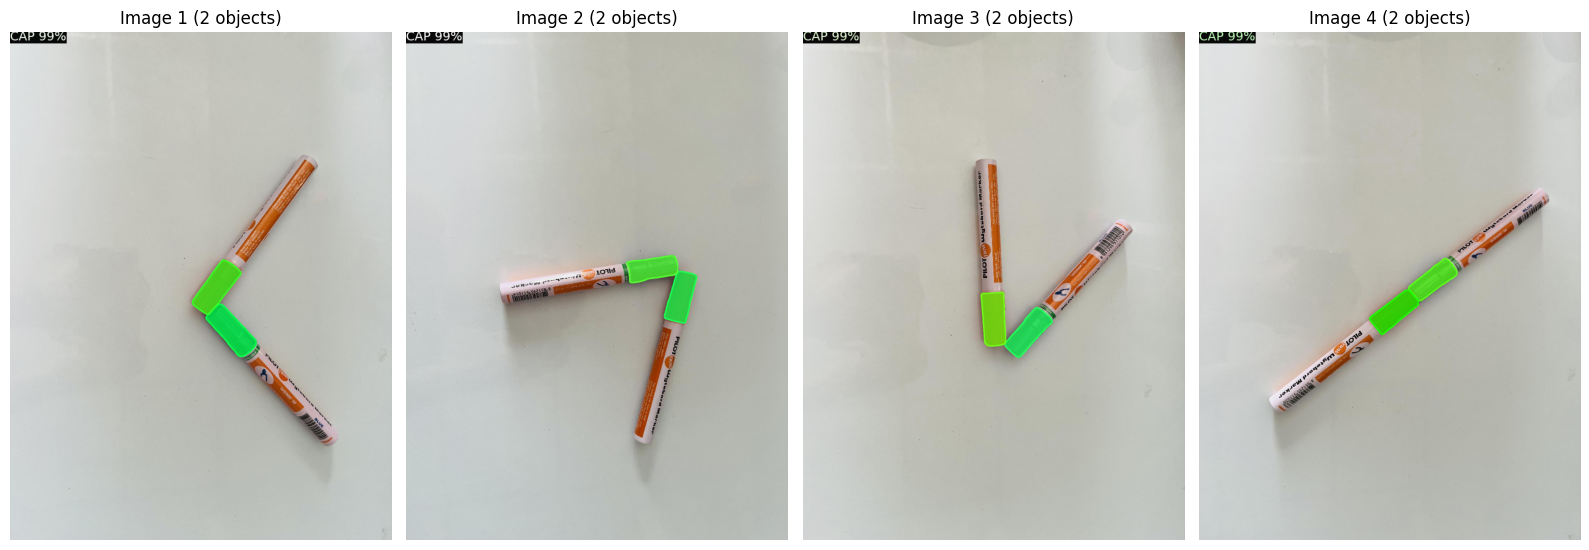

In [43]:
run_inference_on_random_images(4)

In [52]:
def run_inference_on_random_images(num_images):
    predictor = DefaultPredictor(cfg)

    # Assign fixed colors to each category (DO NOT touch class names)
    fixed_colors = [
        (0, 0, 0),     # bg
        (0, 255, 0),     # green
    ]
    MetadataCatalog.get("marker_val").thing_colors = fixed_colors

    metadata = MetadataCatalog.get("marker_val")
    dataset_dicts = DatasetCatalog.get("marker_val")
    sampled_dicts = random.sample(dataset_dicts, num_images)

    # Prepare grid layout
    cols = 4
    rows = math.ceil(num_images / cols)
    plt.figure(figsize=(cols * 4, 6 * rows))

    for idx, d in enumerate(sampled_dicts):
        img_path = d["file_name"]
        img = cv2.imread(img_path)

        # 1. Run prediction
        outputs = predictor(img)

        # 2. MANUAL FILTER: Extract instances and filter by score
        instances = outputs["instances"].to("cpu")
        # Change 0.7 to whatever threshold
        keep = instances.scores > 0.7
        filtered_instances = instances[keep]

        # 2.5 ADD BBOX FROM MASKS
        if len(filtered_instances) > 0:
            masks = filtered_instances.pred_masks  # (N, H, W)

            boxes = []
            for m in masks:
                # 🔥 IMPORTANT: binarize mask correctly
                m = (m > 0.5)

                ys, xs = torch.where(m)

                if ys.numel() == 0:
                    boxes.append([0, 0, 1, 1])
                else:
                    x1 = xs.min().item()
                    y1 = ys.min().item()
                    x2 = xs.max().item()
                    y2 = ys.max().item()
                    boxes.append([x1, y1, x2, y2])

            from detectron2.structures import Boxes
            filtered_instances.pred_boxes = Boxes(torch.tensor(boxes))

        # 3. Initialize Visualizer
        v = Visualizer(
            img[:, :, ::-1],
            metadata=metadata,
            scale=0.5,
            instance_mode=ColorMode.SEGMENTATION,
        )

        # Custom styling
        height, width, _ = img.shape
        v._default_line_width = 10 if width > 800 else 5
        v._default_font_size = 60 if width > 800 else 20
        v._default_alpha = 0.3

        # 4. Draw ONLY the filtered instances
        v = v.draw_instance_predictions(filtered_instances)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(v.get_image())
        plt.axis("off")
        plt.title(f"Image {idx + 1} ({len(filtered_instances)} objects)")

    plt.tight_layout()
    plt.show()

[04/02 09:53:57 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from datasets/best_Mask2Former_marker.pth ...
WARNING [04/02 09:53:57 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[04/02 09:53:57 d2.data.datasets.coco]: Loaded 30 images in COCO format from markerpensseg/valid/_annotations.coco.json


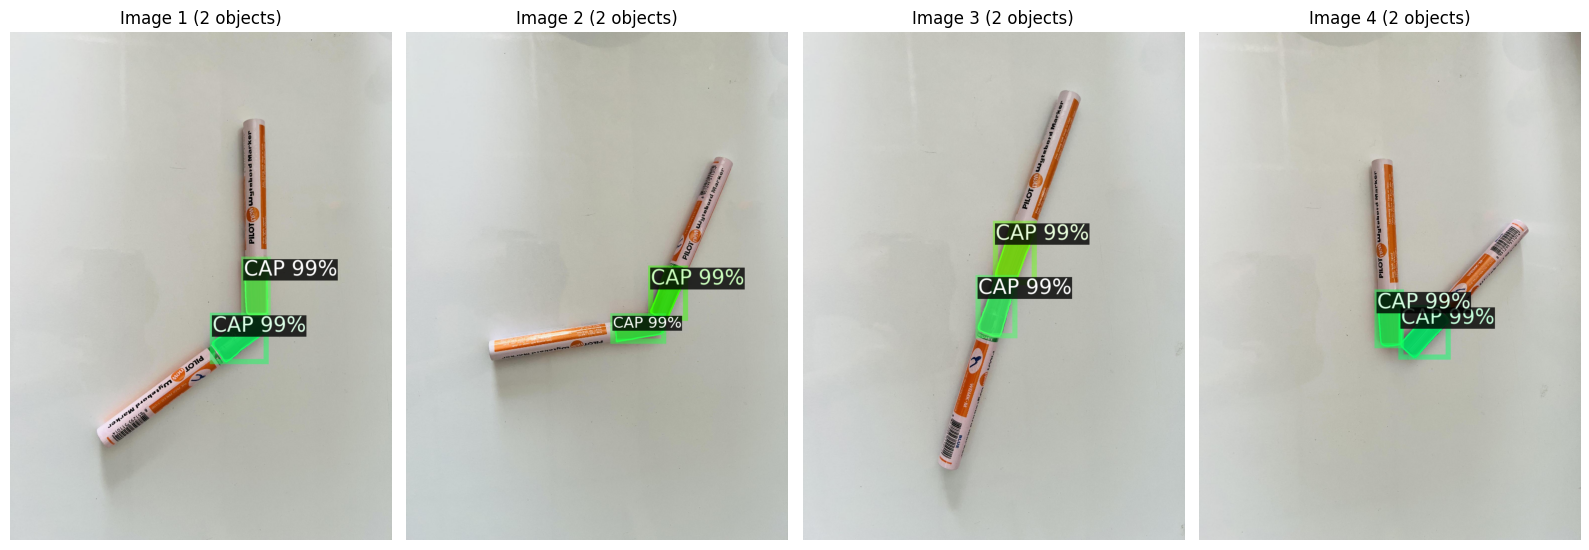

In [53]:
run_inference_on_random_images(4)